# Portfolio problem

In [9]:
import math
from pathlib import Path
import cvxpy as cp
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

from mis_dro.experiments import ExperimentName
from mis_dro.constants import IN_SAMPLE_TIME_WINDOW, OUT_OF_SAMPLE_TIME_WINDOW
from mis_dro.plot import *
from mis_dro.dataset import *

from matplotlib import rc
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], "size":14})
# rc('text', usetex=True)

In [10]:
# mmc2_dir = Path("/", "Users", "patrick", "Datasets", "misdro", "mmc2")
mmc2_dir = Path("/dcs/pg23/u1604520/misdro/datasets/mmc2")
assert mmc2_dir.exists()
dgp = "DowJones-crash"
returns_df = get_portfolio_returns_df(mmc2_dir, dgp)
index_returns_df = pd.read_excel(mmc2_dir / "Datasets" / "DowJones" / f"DowJones.xlsx", sheet_name="Index_Returns", header=None)

In [11]:
experiment_name = ExperimentName.kl_portfolio
experiment_dir1 = Path(f"/dcs/pg23/u1604520/misdro/results/opt_results/mmd_portfolio_crash_diag_M1100_")
experiment_dir2 = Path(f"/dcs/pg23/u1604520/misdro/results/opt_results/kl_portfolio_crash_diag")  #kl_portfolio
experiment_dir3 = Path(f"/dcs/pg23/u1604520/misdro/results/opt_results/kl_portfolio_crash_diag_M1100")
# experiment_dir = Path(f"/Users/patrick/experiments/misdro/{experiment_name.value}")
# assert experiment_dir.exists()

all_results_df1 = pd.read_csv(experiment_dir1 / "results.csv", index_col=["uuid", "replication"])
all_results_df2 = pd.read_csv(experiment_dir2 / "results.csv", index_col=["uuid", "replication"])
all_results_df3 = pd.read_csv(experiment_dir3 / "results.csv", index_col=["uuid", "replication"])
all_results_df = pd.concat([all_results_df1, all_results_df2, all_results_df3])
all_results_df["algorithm"].unique()

array(['dro_bas_mmd', 'kl_dro_bas', 'kl_pp'], dtype=object)

In [12]:
# experiment_dir = Path("/dcs/large/u1508153/misdro/paper_bas/mmd_portfolio")
# assert experiment_dir.exists()
# kl_results_df = pd.read_csv(experiment_dir / "results.csv")
# NOTE filter out when log_partition_constant G is less than epsilon
# results_df = results_df.loc[results_df["log_partition_constant"] < results_df["epsilon"]]
# kl_results_df = kl_results_df.loc[kl_results_df["replication"] < 2].set_index(["uuid", "replication"])
# results_df = pd.concat([results_df, kl_results_df])
# results_df["algorithm"].unique().tolist()

In [13]:
# NOTE filter by DGP
filter_dgp = "DowJones"
dataset = "portfolio"
# results_df = all_results_df.loc[all_results_df["dgp"] == filter_dgp]

results_df = preprocess_results_df(all_results_df, filter_dgp, dataset=dataset)
results_df["algorithm"].unique()

# NOTE filter out when log_partition_constant G is less than epsilon
# results_df = results_df.loc[results_df["log_partition_constant"] < results_df["epsilon"]]

# if "out_of_sample_costs" in results_df.columns:
#     results_df = results_df.rename(columns={"out_of_sample_costs": "out_of_sample_cost"})

# def convert_str_to_float_list(str_list: str, list_len: int) -> list[float]:
#     if str_list == "[]":
#         return[np.nan for _ in range(list_len)]
#     else:
#         return [float(x) for x in str_list.strip('[]').split(',')]

# # NOTE we always want the same number of test observations
# assert np.isclose(results_df["num_test_observations"].var(), 0)
# num_test_observations = results_df["num_test_observations"].unique()[0]
# num_replications = results_df["num_replications"].unique()[0]
# results_df["out_of_sample_cost"] = results_df["out_of_sample_cost"].map(lambda x: convert_str_to_float_list(x, num_test_observations))

# # the log partition constant should always be the same for BAS
# assert np.isclose(results_df.loc[results_df["algorithm"] == "kl_dro_bas"]["log_partition_constant"].var(), 0)
# log_partition_constant = results_df.loc[results_df["algorithm"] == "kl_dro_bas"]["log_partition_constant"].unique()[0]

# # special case for 1 test observation
# if num_test_observations == 1:
#     results_df["out_of_sample_cost"] = results_df["out_of_sample_cost"].map(lambda x: x[0])
# elif num_test_observations > 1 and dataset == "portfolio":
#     results_df["solution"] = results_df["solution"].map(lambda x: convert_str_to_float_list(x, num_test_observations))
# else:
#     raise NotImplementedError("Not supported yet!")


AssertionError: 

In [6]:
# num_total_samples = []
# for _, row in all_results_df.iterrows():
#     if row["algorithm"] in ("kl_bdro", "kl_dro_bas"):
#         num_total_samples.append(row["num_posterior_samples"])
#     else:
#         raise NotImplementedError()
# results_df["num_total_samples"] = num_total_samples

# results_df["sample_time"] = results_df["likelihood_time"] + results_df["posterior_time"]
# gb = results_df.groupby(["algorithm", "num_total_samples"])
# solve_time_df = gb.agg(
#     mean_solve_time = pd.NamedAgg(column="solve_time", aggfunc=np.mean),
#     std_solve_time = pd.NamedAgg(column="solve_time", aggfunc=np.std),
#     mean_sample_time = pd.NamedAgg(column="sample_time", aggfunc=np.mean),
#     std_sample_time = pd.NamedAgg(column="sample_time", aggfunc=np.std),
# )
# solve_time_df = solve_time_df.round(decimals=4)
# solve_time_df["str_solve_time"] = solve_time_df[["mean_solve_time", "std_solve_time"]].apply(
#     lambda x: f"{x['mean_solve_time']} ({x['std_solve_time']})", axis=1
# )
# solve_time_df["str_sample_time"] = solve_time_df[["mean_sample_time", "std_sample_time"]].apply(
#     lambda x: f"{x['mean_sample_time']} ({x['std_sample_time']})", axis=1
# )
# print(solve_time_df[["str_solve_time", "str_sample_time"]].to_latex())



In [6]:
# now only look at 30 posterior samples for BDRO
num_samples = 900
results_df = results_df.loc[(results_df["algorithm"] != "kl_bdro") | (results_df["num_posterior_samples"] == num_samples)]
results_df = results_df.loc[(results_df["algorithm"] != "kl_pp") | (results_df["num_likelihood_samples"] == num_samples)]

# results_df = results_df.loc[results_df["replication"] == ]

assert np.isclose(results_df.loc[results_df["algorithm"] == "kl_dro_bas"]["log_partition_constant"].var(), 0)
log_partition_constant = results_df.loc[results_df["algorithm"] == "kl_dro_bas"]["log_partition_constant"].unique()[0]

agg_df = get_agg_df(results_df, gb_cols=["algorithm", "epsilon"])
agg_df

NameError: name 'results_df' is not defined

NameError: name 'agg_df' is not defined

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: 

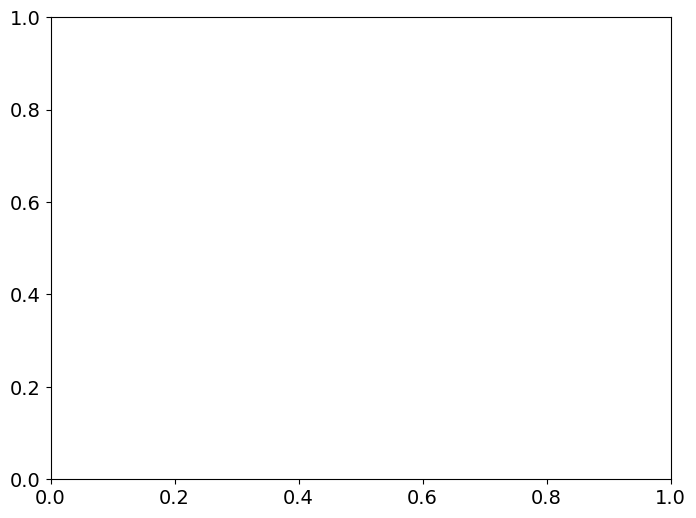

In [7]:
fig, ax = plt.subplots(figsize=(8,6))
df = agg_df
df.loc[:, "is_pareto_front"] = is_maximise_pareto_front(df["out_of_sample_var"].values, df["out_of_sample_mean"].values)
for algorithm, group_df in df.groupby("algorithm"):
    if algorithm == "kl_dro_bas":
        local_log_partition_constant = log_partition_constant
    else:
        local_log_partition_constant = 0
    if algorithm == "kl_dro_bas" or algorithm == "kl_pp" or algorithm == "kl_bdro":
        inference = "bayes"
    elif algorithm == "empirical_mmd":
        inference = "empirical"
    else:
        inference = "npl_mmd"
    mean_variance_plot(ax, group_df, is_labelled=True, offset=0.00003, alpha=1.0, **algorithm_inference_style(algorithm, inference), special_epsilons=[0.00001, 0.001, 0.01, 1.0], add_log_partition_function=local_log_partition_constant)
    #  log_partition_constant=local_log_partition_constant
# handles, labels = ax.get_legend_handles_labels()
# order = [1,0]
# ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order])
ax.legend()
ax.set_xlabel("Out-of-sample variance")
ax.set_ylabel("Out-of-sample mean")
# ax.set_xlim(agg_df["out_of_sample_var"].min(), agg_df["out_of_sample_var"].max())
# ax.set_ylim(agg_df["out_of_sample_mean"].min(), agg_df["out_of_sample_mean"].min())
# fig.savefig(f"/Users/patrick/Experiments/misdro/paper_bas_figures/{experiment_name}_mean_var_{filter_dgp}.pdf", bbox_inches="tight")

fig.show()

NameError: name 'results_df' is not defined

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: 

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: 

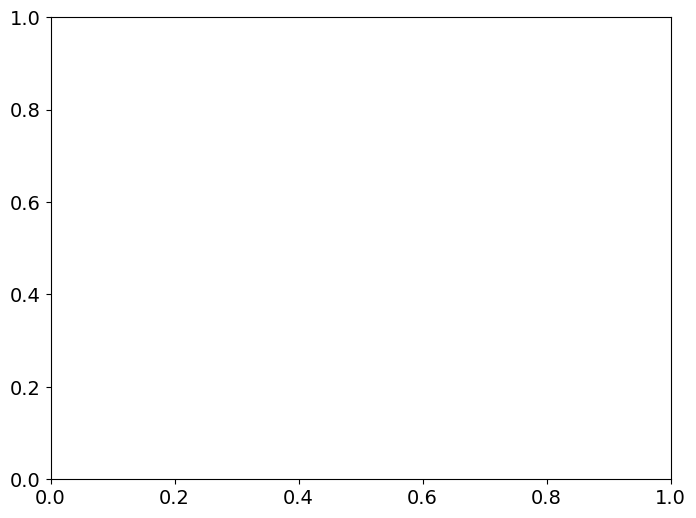

In [8]:
fig, ax = plt.subplots(figsize=(8,6))
num_replications = results_df["num_replications"].unique()[0]
num_time_windows = math.floor((len(returns_df) - IN_SAMPLE_TIME_WINDOW) / OUT_OF_SAMPLE_TIME_WINDOW)
num_stocks = int(len(returns_df.columns))
last_week = len(index_returns_df.iloc[IN_SAMPLE_TIME_WINDOW:])
bdro_labelled = False
dro_bas_labelled = False
robas_labelled = False
oos_week_numbers = [IN_SAMPLE_TIME_WINDOW + i for i in range(OUT_OF_SAMPLE_TIME_WINDOW * num_time_windows)]
for (algorithm, epsilon), group_df in results_df.groupby(["algorithm", "epsilon"]):
    # dro_returns = group_df[week_cols].values.flatten()
    assert OUT_OF_SAMPLE_TIME_WINDOW * num_time_windows == len(group_df) * len(group_df["out_of_sample_cost"].values[0])
    cost_list = []
    for i in range(num_replications):
        cost_list += group_df["out_of_sample_cost"].values[i]
    dro_returns = np.array(cost_list)
    if not dro_bas_labelled and algorithm == "kl_dro_bas":
        label = AlgorithmName[algorithm].value
        dro_bas_labelled = True
    elif not bdro_labelled and algorithm == "kl_bdro":
        label = AlgorithmName[algorithm].value
        bdro_labelled = True
    elif not robas_labelled and algorithm == "dro_bas_mmd":
        label = AlgorithmName[algorithm].value
        robas_labelled = True
    else:
        label='_nolegend_'
    ax.plot(oos_week_numbers, np.cumsum(dro_returns), label=label, alpha=0.3, color=AlgorithmColor[algorithm].value)
    if algorithm == "kl_dro_bas" and epsilon in [0.00001, 0.001, 0.01, 1.0]:
        ax.text(last_week + IN_SAMPLE_TIME_WINDOW, np.cumsum(dro_returns)[last_week-4]-0.1, np.round(log_partition_constant + epsilon, 5), color=AlgorithmColor[algorithm].value)
    elif algorithm == "kl_bdro" and  epsilon in [0.00002, 0.001, 0.01]:
        ax.text(last_week + IN_SAMPLE_TIME_WINDOW, np.cumsum(dro_returns)[last_week-4]-0.1, epsilon, color=AlgorithmColor[algorithm].value)
    elif algorithm == "dro_bas_mmd" and  epsilon in [0.00002, 0.001, 0.01]:
        ax.text(last_week + IN_SAMPLE_TIME_WINDOW, np.cumsum(dro_returns)[last_week-4]-0.1, epsilon, color=AlgorithmColor[algorithm].value)

CB_color_cycle = ['#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']
ax.plot(oos_week_numbers, np.cumsum(index_returns_df.iloc[IN_SAMPLE_TIME_WINDOW:IN_SAMPLE_TIME_WINDOW+OUT_OF_SAMPLE_TIME_WINDOW * num_time_windows].values), label=f"{dgp} Index", color=CB_color_cycle[0])
# for baseline_model in ["CZeSD", "KP_SSD", "L_SSD", "LR_ASSD", "MeanVar", "RMZ_SSD"]:

for i, baseline_model in enumerate(["MeanVar"]):
    baseline_model_label = baseline_model if baseline_model != "MeanVar" else "Markowitz"
    baseline_portfolio_txt = mmc2_dir / "Solutions" / dgp / f"OptPortfolios_{baseline_model}_{dgp}.txt"
    baseline_portfolio = np.loadtxt(baseline_portfolio_txt).T[:num_time_windows, :]
    baseline_returns_txt = mmc2_dir / "Solutions" / dgp / f"OutofSamplePortReturns_{baseline_model}_{dgp}_List.txt" 
    baseline_returns = np.loadtxt(baseline_returns_txt)
    ax.plot(oos_week_numbers, np.cumsum(baseline_returns[:OUT_OF_SAMPLE_TIME_WINDOW * num_time_windows]), label=baseline_model_label, color=CB_color_cycle[i+1])

ax.set_xlabel("Week number")
ax.set_ylabel("Out-of-sample cumulative return")
# ax.set_xlim(2000)
ax.set_xlim(0, 1520)
ax.set_ylim(-0.1, 9.5)
ax.vlines(52, -0.3, 6.9, color="black", linestyle=":")
# ax.set_title(dgp + r" cumulative return vs Benchmarks")
handles, labels = ax.get_legend_handles_labels()
order = [1,0,2,3]
ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order])
# ax.legend()
# plt.savefig(f"/Users/patrick/Experiments/misdro/paper_bas_figures/{experiment_name}_cum_returns_{filter_dgp}.pdf", bbox_inches="tight")

fig.show()

In [ ]:
bas_returns = []
bdro_returns = []
filter_epsilon = 0.1
for (algorithm, epsilon), group_df in gb:
    # dro_returns = group_df[week_cols].values.flatten()
    if algorithm == "kl_dro_bas" and epsilon == filter_epsilon:
        assert OUT_OF_SAMPLE_TIME_WINDOW * num_time_windows == len(group_df) * len(group_df["out_of_sample_cost"].values[0])
        for i in range(num_replications):
            bas_returns += group_df["out_of_sample_cost"].values[i]
    if algorithm == "kl_bdro" and epsilon == filter_epsilon:
        assert OUT_OF_SAMPLE_TIME_WINDOW * num_time_windows == len(group_df) * len(group_df["out_of_sample_cost"].values[0])
        for i in range(num_replications):
            bdro_returns += group_df["out_of_sample_cost"].values[i]
plt.hist(bas_returns, bins=50, label="BAS", alpha=0.5)
plt.hist(bdro_returns, bins=50, label="BDRO", alpha=0.5)
plt.legend()

NameError: name 'gb' is not defined

In [55]:
from mis_dro.dataset import portfolio_dataset
training_time_window = 72
data, data_eval = portfolio_dataset("DowJones", training_time_window, mmc2_dir)
dim = data.shape[1]
sol = np.ones(dim) / float(dim)

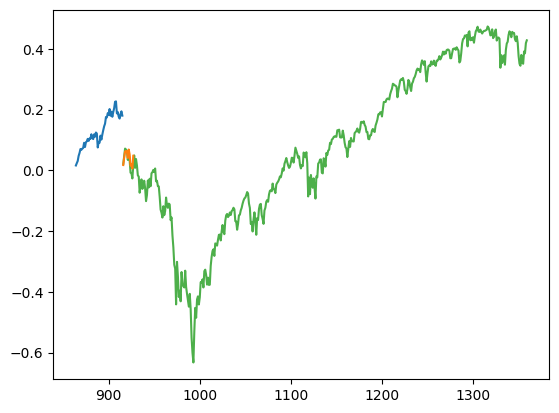

In [56]:


start_training_week = training_time_window * OUT_OF_SAMPLE_TIME_WINDOW # inclusive
end_training_week = start_training_week + IN_SAMPLE_TIME_WINDOW # not inclusive
test_start = end_training_week
test_end = test_start + OUT_OF_SAMPLE_TIME_WINDOW

plt.plot(oos_week_numbers[start_training_week:], np.cumsum(index_returns_df.iloc[start_training_week + IN_SAMPLE_TIME_WINDOW:IN_SAMPLE_TIME_WINDOW+OUT_OF_SAMPLE_TIME_WINDOW * num_time_windows].values), label=f"{dgp} Index", color=CB_color_cycle[0])


plt.plot(oos_week_numbers[start_training_week - IN_SAMPLE_TIME_WINDOW:end_training_week - IN_SAMPLE_TIME_WINDOW], (data @ sol).cumsum())
plt.plot(oos_week_numbers[test_start - IN_SAMPLE_TIME_WINDOW:test_end - IN_SAMPLE_TIME_WINDOW], (data_eval @ sol).cumsum())


In [4]:
from mis_dro.bayes_conjugates import *
from mis_dro.dataset import portfolio_dataset

In [5]:
dgp = "DowJones"
replication = 0

mmc2_dir = Path("/dcs/pg23/u1604520/misdro/datasets/mmc2")
assert mmc2_dir.exists()
# returns_df = pd.read_excel(mmc2_dir / "Datasets" / dgp / f"{dgp}.xlsx", sheet_name="Assets_Returns", header=None)
data, data_eval = portfolio_dataset(dgp, replication, mmc2_dir)

num_posterior_samples = 1
dim = data.shape[1]

In [6]:
posterior = "multivariate_normal_diag"

In [7]:
theta_prior = default_prior_params(posterior, dim=dim)
theta_posterior = get_posterior_params(posterior, data, theta_prior)

In [8]:
log_partition_constant = get_log_partition_constant(posterior, theta_posterior)
theta_sample = derive_analytical_posterior_params(posterior, theta_posterior)

In [9]:
theta_sample

array([[ 0.0121446 ,  0.0165031 ,  0.00238752,  0.0079212 ,  0.00286761,
         0.00544238, -0.00554503,  0.00301111,  0.0120561 ,  0.0089639 ,
         0.0097825 ,  0.00115711,  0.01561412,  0.00242977,  0.00570073,
         0.00606779,  0.00752382,  0.02203918,  0.02573138,  0.00040526,
         0.00294188,  0.01196956,  0.0042464 , -0.00053881,  0.00019764,
         0.00089116, -0.00090381,  0.00352475,  0.04057533,  0.04100913,
         0.03770421,  0.03823524,  0.03825088,  0.03859809,  0.04258008,
         0.0387068 ,  0.03983371,  0.03842409,  0.0388272 ,  0.03789782,
         0.04092908,  0.03908122,  0.04066143,  0.03821686,  0.03831963,
         0.04402028,  0.04295745,  0.03881216,  0.03786503,  0.04141063,
         0.03938676,  0.03832867,  0.04025129,  0.038403  ,  0.03881895,
         0.03826569]])

crash

In [14]:
results_df = preprocess_results_df(all_results_df, "DowJones-crash", dataset="portfolio")
agg_df = get_agg_df(results_df, gb_cols=["algorithm", "epsilon", "inference"])
agg_df

/dcs/pg23/u1604520/mis-dro-code/mis_dro/plot.py:193: FutureWarning: The provided callable <function mean at 0x7efe446b31a0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg23/u1604520/mis-dro-code/mis_dro/plot.py:193: FutureWarning: The provided callable <function std at 0x7efe446b32e0> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(


out_of_sample_mean  out_of_sample_var  \
algorithm   epsilon inference                                          
dro_bas_mmd 0.00010 npl_mmd             -0.004055           0.005959   
            0.00050 npl_mmd             -0.004055           0.005959   
            0.00100 npl_mmd             -0.004132           0.005534   
            0.00300 npl_mmd             -0.006254           0.004025   
            0.00500 npl_mmd             -0.005903           0.003526   
            0.01000 npl_mmd             -0.005207           0.003488   
            0.05000 npl_mmd             -0.004329           0.002889   
            0.10000 npl_mmd             -0.004160           0.002711   
            0.15000 npl_mmd             -0.004482           0.002946   
            0.20000 npl_mmd             -0.004215           0.002876   
            0.25000 npl_mmd             -0.004290           0.002778   
            0.30000 npl_mmd             -0.004629           0.002520   
            0.40000 npl_mmd             -0.004951           0.002861   
            0.50000 npl_mmd             -0.004920           0.002873   
            1.00000 npl_mmd             -0.004846           0.002411   
kl_dro_bas  0.00001 bayes               -0.004028           0.006336   
            0.00002 bayes               -0.004028           0.006336   
            0.00005 bayes               -0.004028           0.006336   
            0.00010 bayes               -0.004028           0.006336   
            0.00020 bayes               -0.004028           0.006336   
            0.00050 bayes               -0.004028           0.006336   
            0.00100 bayes               -0.003839           0.004038   
            0.00200 bayes               -0.004215           0.002902   
            0.00500 bayes               -0.004307           0.002441   
            0.01000 bayes               -0.004347           0.002460   
            0.02000 bayes               -0.004397           0.002546   
            0.05000 bayes               -0.004363           0.002621   
            0.10000 bayes               -0.004324           0.002661   
            0.20000 bayes               -0.004298           0.002688   
            0.50000 bayes               -0.004276           0.002713   
            1.00000 bayes               -0.004265           0.002726   
kl_pp       0.00001 bayes               -0.002274           0.009669   
            0.00002 bayes               -0.002078           0.009304   
            0.00005 bayes               -0.001911           0.009024   
            0.00010 bayes               -0.001828           0.008895   
            0.00020 bayes               -0.001769           0.008810   
            0.00050 bayes               -0.000937           0.009002   
            0.00100 bayes               -0.000876           0.008622   
            0.00200 bayes               -0.001161           0.007156   
            0.00500 bayes               -0.002056           0.005382   
            0.01000 bayes               -0.002509           0.004839   
            0.02000 bayes               -0.002929           0.004183   
            0.05000 bayes               -0.003364           0.003646   
            0.10000 bayes               -0.003700           0.003388   
            0.20000 bayes               -0.003879           0.003169   
            0.50000 bayes               -0.004038           0.002998   
            1.00000 bayes               -0.004143           0.002911   

                               sum_of_in_group_var  var_of_in_group_mean  \
algorithm   epsilon inference                                              
dro_bas_mmd 0.00010 npl_mmd               0.005959                   NaN   
            0.00050 npl_mmd               0.005959                   NaN   
            0.00100 npl_mmd               0.005534                   NaN   
            0.00300 npl_mmd               0.004025                   NaN   
            0.00500 npl_mmd               0.00

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: 

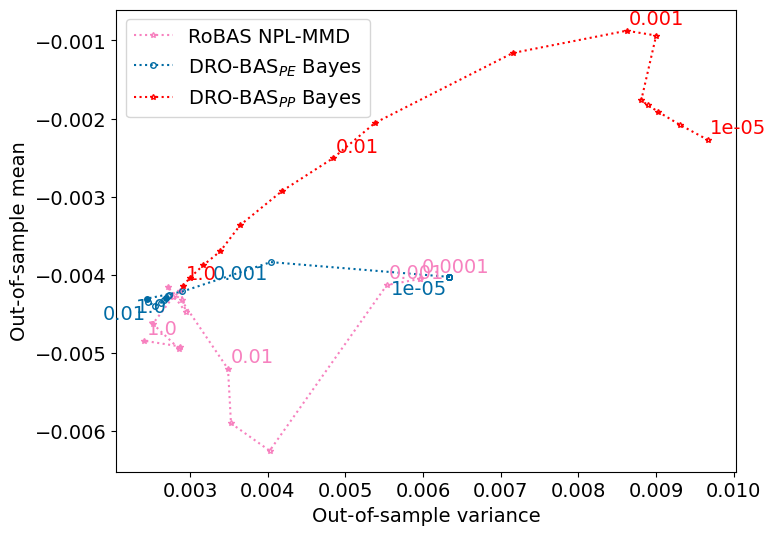

In [15]:
log_partition_constant = results_df.loc[results_df["algorithm"] == "kl_dro_bas"]["log_partition_constant"].unique()[0]
fig, ax = plt.subplots(figsize=(8,6))
df = agg_df
df.loc[:, "is_pareto_front"] = is_maximise_pareto_front(df["out_of_sample_var"].values, df["out_of_sample_mean"].values)
for (algorithm, inference), group_df in df.groupby(["algorithm", "inference"]):
    if algorithm == "kl_dro_bas":
        local_log_partition_constant = log_partition_constant
    else:
        local_log_partition_constant = 0
    mean_variance_plot(ax, group_df, is_labelled=True, offset=0.00003, alpha=1.0, **algorithm_inference_style(algorithm, inference), special_epsilons=[0.00001, 0.001, 0.01, 1.0])
ax.set_xlabel("Out-of-sample variance")
ax.set_ylabel("Out-of-sample mean")
ax.legend()
fig.show()

In [16]:
num_replications = results_df["num_replications"].unique()[0]
out_of_sample_time_window = IN_SAMPLE_TIME_WINDOW
num_time_windows = 1
num_stocks = int(len(returns_df.columns))
bdro_labelled = False
dro_bas_labelled = False
training_time_window_id = 75
oos_week_numbers = [training_time_window_id * OUT_OF_SAMPLE_TIME_WINDOW + IN_SAMPLE_TIME_WINDOW + i for i in range(out_of_sample_time_window)]
last_week = oos_week_numbers[len(oos_week_numbers)-1]

start_training_week = training_time_window_id * OUT_OF_SAMPLE_TIME_WINDOW # inclusive
end_training_week = start_training_week + IN_SAMPLE_TIME_WINDOW # not inclusive
test_start = end_training_week
test_end = test_start + out_of_sample_time_window

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: 

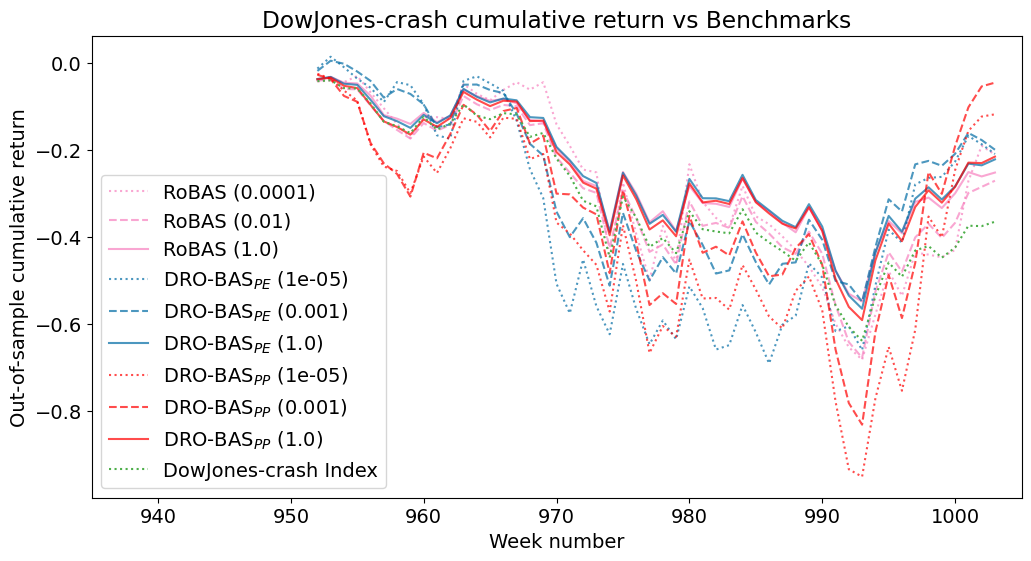

In [18]:
fig, ax = plt.subplots(figsize=(12,6))

epsilon_list = [0.00001, 0.001, 1.0]
robas_epsilon_list = [0.0001, 0.01, 1.0]
line_styles = ["dotted" , "dashed" , "solid"]

for (algorithm, epsilon), group_df in results_df.groupby(["algorithm", "epsilon"]):
    # dro_returns = group_df[week_cols].values.flatten()
    # assert OUT_OF_SAMPLE_TIME_WINDOW * num_time_windows == len(group_df) * len(group_df["out_of_sample_cost"].values[0])
    cost_list = []
    for i in range(num_replications):
        cost_list += group_df["out_of_sample_cost"].values[i]
    dro_returns = np.array(cost_list)
    # if not dro_bas_labelled and algorithm == "kl_dro_bas":
    #     label = AlgorithmName[algorithm].value
    #     dro_bas_labelled = True
    # elif not bdro_labelled and algorithm == "kl_bdro":
    #     label = AlgorithmName[algorithm].value
    #     bdro_labelled = True
    # else:
    #     label='_nolegend_'
    is_robas_experiment = algorithm in ("dro_bas_mmd", "empirical_mmd")
    label = AlgorithmName[algorithm].value + f" ({epsilon})"
    if (epsilon in epsilon_list and not is_robas_experiment) or (epsilon in robas_epsilon_list and is_robas_experiment):
        idx = robas_epsilon_list.index(epsilon) if is_robas_experiment else epsilon_list.index(epsilon)
        ax.plot(oos_week_numbers, np.cumsum(dro_returns), label=label, alpha=0.7, color=AlgorithmColor[algorithm].value, linestyle=line_styles[idx])
    # if algorithm == "kl_dro_bas" and epsilon in epsilon_list:
    #     ax.text(last_week, np.cumsum(dro_returns)[test_end-4-end_training_week], np.round(log_partition_constant + epsilon, 5), color=AlgorithmColor[algorithm].value)
    # elif algorithm == "kl_bdro" and  epsilon in [0.00002, 0.001, 0.01]:
    #     ax.text(last_week, np.cumsum(dro_returns)[last_week-4-end_training_week]-0.1, epsilon, color=AlgorithmColor[algorithm].value)

CB_color_cycle = ['#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']
ax.plot(oos_week_numbers, np.cumsum(index_returns_df.iloc[test_start:test_end].values), label=f"{dgp} Index", color=CB_color_cycle[0], linestyle="dotted")
# for baseline_model in ["CZeSD", "KP_SSD", "L_SSD", "LR_ASSD", "MeanVar", "RMZ_SSD"]:

for i, baseline_model in enumerate(["MeanVar"]):
    baseline_model_label = baseline_model if baseline_model != "MeanVar" else "Markowitz"
    baseline_portfolio_txt = mmc2_dir / "Solutions" / "DowJones" / f"OptPortfolios_{baseline_model}_DowJones.txt"
    baseline_portfolio = np.loadtxt(baseline_portfolio_txt).T[:num_time_windows, :]
    baseline_returns_txt = mmc2_dir / "Solutions" / "DowJones" / f"OutofSamplePortReturns_{baseline_model}_DowJones_List.txt" 
    baseline_returns = np.loadtxt(baseline_returns_txt)
    # ax.plot(oos_week_numbers, np.cumsum(baseline_returns[test_start-IN_SAMPLE_TIME_WINDOW:test_end-IN_SAMPLE_TIME_WINDOW]), label=baseline_model_label, color=CB_color_cycle[i+1])

ax.set_xlabel("Week number")
ax.set_ylabel("Out-of-sample cumulative return")
# ax.set_xlim(2000)
ax.set_xlim(935, 1005)
# ax.set_ylim(-0.1, 9.5)
# ax.vlines(52, -0.3, 6.9, color="black", linestyle=":")
ax.set_title(dgp + r" cumulative return vs Benchmarks")
handles, labels = ax.get_legend_handles_labels()
order = [1,0,2,3]
# ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order])
ax.legend()
# plt.savefig(f"/Users/patrick/Experiments/misdro/paper_bas_figures/{experiment_name}_cum_returns_{filter_dgp}.pdf", bbox_inches="tight")

fig.show()